# PLL Verification

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from rfmodel.core.config import load_yaml
from rfmodel.core.signal import Signal
from rfmodel.core.pipeline_builder import pipeline_from_config
from rfmodel.meas.phase_noise_analyser import calculate_phase_noise_curve
import rfmodel.rf.registry
import scipy.signal as signal

cfg = load_yaml(r".\PLL_mixer.yaml")
pipe = pipeline_from_config(cfg)


In [2]:
mixer = pipe.get("mixer_and_pll")

# runtime control
mixer.params.mixer_ideal = True
mixer.params.pll.enable_ofdm_weighting = False

In [3]:
fs = 10e6
N = int(2**24)  # Increased from 2**14 to get ~16 Welch averages for a smooth curve
t = np.arange(N) / fs
f0 = 1e3
x = np.exp(1j * 2 * np.pi * f0 * t)
sig = Signal(x=x, fs_hz=fs, meta={})
out = mixer.process(sig)
y = np.asarray(out.x, dtype=complex).flatten()

## Generating Phase Noise Curve

Phase noise at 1.000 MHz offset: -90.01 dBc/Hz


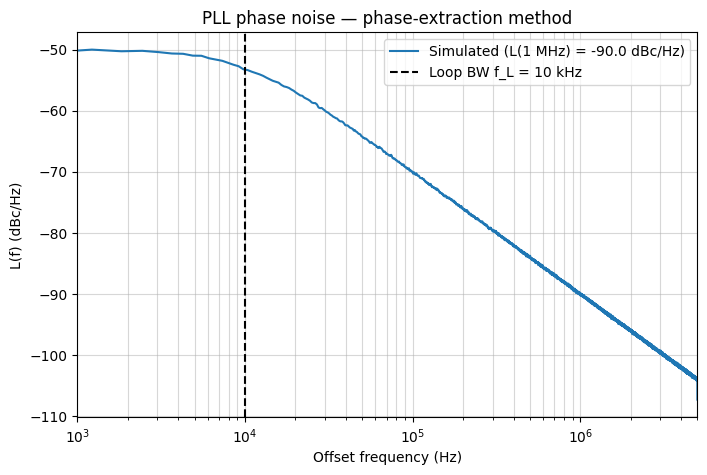

In [4]:
# Extract phase noise from the output and plot the single-sideband curve
offsets_pe, L_f, pn_at_offset = calculate_phase_noise_curve(
    y, fs=fs, target_offset=1e6,
)

f_L = mixer.params.pll.f_L

plt.figure(figsize=(8, 5))
plt.semilogx(offsets_pe, L_f, label=f"Simulated (L(1 MHz) = {pn_at_offset:.1f} dBc/Hz)")
plt.axvline(f_L, ls='--', color='k', label=f"Loop BW f_L = {f_L/1e3:.0f} kHz")
plt.xlabel("Offset frequency (Hz)")
plt.ylabel("L(f) (dBc/Hz)")
plt.title("PLL phase noise — phase-extraction method")
plt.xlim(1e3, fs/2)
plt.grid(True, which="both", alpha=0.5)
plt.legend()
plt.show()